
Found 4684 files belonging to 3 classes.
Using 3748 files for training.
Found 4684 files belonging to 3 classes.
Using 936 files for validation.
Classes (in order): ['Bacterialblight', 'Brownspot', 'Leafsmut']


Model: "efficientnet_rice"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)          

C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/118 - 78s - loss: 0.5323 - accuracy: 0.7927 - val_loss: 0.2807 - val_accuracy: 0.9391 - lr: 0.0010 - 78s/epoch - 663ms/step
Epoch 2/20
118/118 - 69s - loss: 0.2646 - accuracy: 0.9312 - val_loss: 0.1907 - val_accuracy: 0.9605 - lr: 0.0010 - 69s/epoch - 582ms/step
Epoch 3/20
118/118 - 66s - loss: 0.2027 - accuracy: 0.9461 - val_loss: 0.1451 - val_accuracy: 0.9701 - lr: 0.0010 - 66s/epoch - 560ms/step
Epoch 4/20
118/118 - 65s - loss: 0.1565 - accuracy: 0.9621 - val_loss: 0.1177 - val_accuracy: 0.9765 - lr: 0.0010 - 65s/epoch - 552ms/step
Epoch 5/20
118/118 - 68s - loss: 0.1411 - accuracy: 0.9632 - val_loss: 0.1002 - val_accuracy: 0.9818 - lr: 0.0010 - 68s/epoch - 576ms/step
Epoch 6/20
118/118 - 71s - loss: 0.1149 - accuracy: 0.9701 - val_loss: 0.0867 - val_accuracy: 0.9797 - lr: 0.0010 - 71s/epoch - 602ms/step
Epoch 7/20
118/118 - 66s - loss: 0.1002 - accuracy: 0.9771 - val_loss: 0.0758 - val_accuracy: 0.9882 - lr: 0.0010 - 66s/epoch - 556ms/step
Epoch 8/20
118/118 - 65s - loss: 0.093

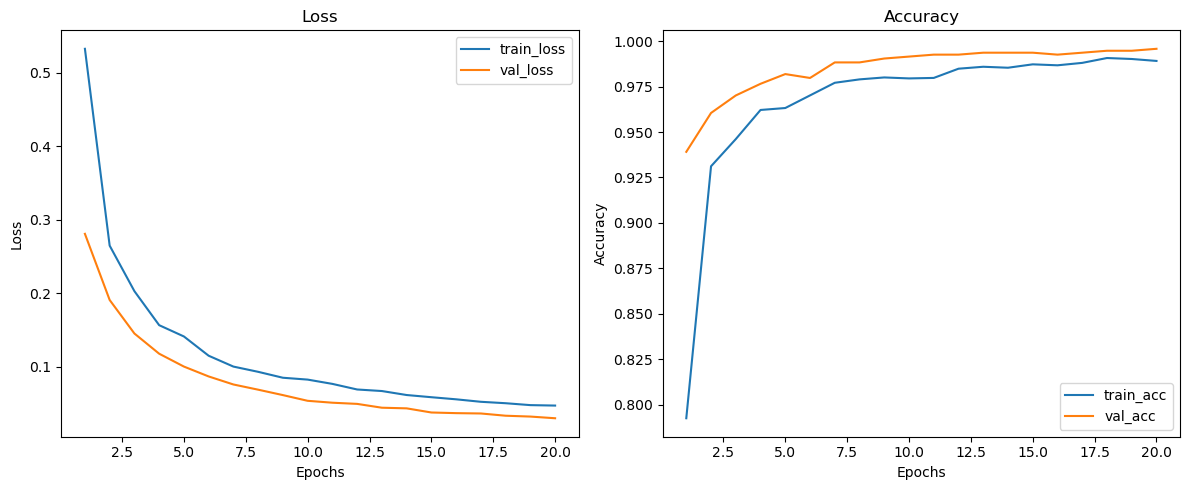


Confusion Matrix (rows=true, cols=pred) as numpy array:
[[309   0   0]
 [  0 348   0]
 [  1   3 275]]

Class index mapping:
0 -> Bacterialblight
1 -> Brownspot
2 -> Leafsmut

Classification Report:
                 precision    recall  f1-score   support

Bacterialblight     0.9968    1.0000    0.9984       309
      Brownspot     0.9915    1.0000    0.9957       348
       Leafsmut     1.0000    0.9857    0.9928       279

       accuracy                         0.9957       936
      macro avg     0.9961    0.9952    0.9956       936
   weighted avg     0.9958    0.9957    0.9957       936



C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Saved model to rice_disease_model_final.h5


In [1]:
# rice_disease_classifier.py
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------
# Config
# -------------------------
DATA_DIR = r"D:\Raushan\paddy_data\rice leaf diseases dataset"
IMG_SIZE = (224, 224)     # image size for EfficientNetB0
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.2
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 20               # start with 20, you can increase later
FINE_TUNE_AT = 100        # layer index to start fine-tuning (optional)
MODEL_SAVE_PATH = "rice_disease_model.h5"

# -------------------------
# Load datasets (train/validation) from directory (unbalanced data kept as-is)
# -------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes (in order):", class_names)

# Prefetch for performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# -------------------------
# Data augmentation layer (on-the-fly)
# -------------------------
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="data_augmentation",
)

# -------------------------
# Build model (transfer learning: EfficientNetB0)
# -------------------------
inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)                           # augment only during training
x = keras.applications.efficientnet.preprocess_input(x)  # preprocessing for EfficientNet

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, input_shape=(*IMG_SIZE, 3), weights="imagenet"
)
base_model.trainable = False  # freeze base for initial training

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="efficientnet_rice")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),  # labels are integer encoded
    metrics=["accuracy"],
)

model.summary()

# -------------------------
# Callbacks
# -------------------------
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

# -------------------------
# Train (initial)
# -------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

# -------------------------
# Plot training curves (loss & accuracy)
# -------------------------
def plot_history(history):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="train_acc")
    plt.plot(epochs, hist["val_accuracy"], label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# -------------------------
# Optionally: Fine-tune (unfreeze some of the base model)
# -------------------------
# If you want to fine-tune for a few more epochs, uncomment below block:
# -----------------------------------------------------------------------
# base_model.trainable = True
# # Freeze all layers before FINE_TUNE_AT
# for layer in base_model.layers[:FINE_TUNE_AT]:
#     layer.trainable = False
#
# model.compile(
#     optimizer=keras.optimizers.Adam(1e-5),  # lower LR for fine-tuning
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     metrics=["accuracy"],
# )
#
# fine_tune_epochs = 10
# total_epochs = EPOCHS + fine_tune_epochs
# history_fine = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=total_epochs,
#     initial_epoch=history.epoch[-1] + 1,
#     callbacks=callbacks,
#     verbose=2
# )
#
# # Merge histories if desired:
# # (left as an exercise if you want to inspect combined training curves)
# -----------------------------------------------------------------------

# -------------------------
# Confusion matrix on validation set (printed as numpy array)
# -------------------------
# Build arrays of true labels and predicted labels for the validation dataset
y_true = []
y_pred = []

# We need to iterate through val_ds to collect labels and predictions.
for batch_images, batch_labels in val_ds:
    preds = model.predict(batch_images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_pred.append(pred_labels)
    y_true.append(batch_labels.numpy())

# concatenate batches
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Compute confusion matrix (as numpy array)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (rows=true, cols=pred) as numpy array:")
print(cm)

# Also print a readable mapping of class indexes
print("\nClass index mapping:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Optional: classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# -------------------------
# Save final model (already saved by ModelCheckpoint but save again if you want)
# -------------------------
model.save("rice_disease_model_final.h5")
print("\nSaved model to rice_disease_model_final.h5")


In [11]:
import tensorflow as tf
import numpy as np
import os

# -----------------------------
# Config
# -----------------------------
MODEL_PATH = "rice_disease_model_final.h5"
IMG_SIZE = (224, 224)

# Must match your training class order exactly
CLASS_NAMES = ["Bacterialblight", "Brownspot", "Leafsmut"]

# -----------------------------
# Load Model
# -----------------------------
print("[INFO] Loading trained model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("[INFO] Model loaded successfully!\n")

# -----------------------------
# Function to predict a single image
# -----------------------------
def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"[ERROR] File not found: {image_path}")
        return

    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(np.max(preds[0]))

    print(f"Predicted Class : {pred_class}")
    print(f"Confidence      : {confidence*100:.2f}%\n")
    print("Class Probabilities:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:15s} -> {preds[0][i]*100:.2f}%")

# -----------------------------
# Run on your test image
# -----------------------------
image_path = r"D:\Raushan\paddy_data\rice leaf diseases dataset\Leafsmut\BLAST1_115.jpg"
predict_image(image_path)


[INFO] Loading trained model...
[INFO] Model loaded successfully!

Predicted Class : Leafsmut
Confidence      : 81.62%

Class Probabilities:
  Bacterialblight -> 18.38%
  Brownspot       -> 0.00%
  Leafsmut        -> 81.62%
